#  **Autonomous Driving – Binary Classification**

## **Table of Contents**

1. Project Overview
2. Import Required Libraries
3. Dataset Understanding
4. Exploratory Data Analysis


## **Project Overview**

**Problem Statement**

This project focuses on a binary image classification task in which road scene images are classified into one of two lighting conditions:

- Day
- Night

Accurately identifying the lighting condition is an important preprocessing step for autonomous driving systems, as different environmental conditions often require different perception and decision-making strategies.

---

**Objective**

The primary objective of this project is to develop a deep learning model capable of automatically classifying an input road scene image as either **Day** or **Night**.

The project covers the complete machine learning workflow, including:

- Data exploration
- Data preprocessing
- Model development
- Model training
- Model evaluation
- Prediction on unseen images

---

**Classes**

-  Day
- Night

---

**Expected Output**

The final deliverable will be an interactive web application that allows users to:

- Upload a road scene image
- Predict whether the image represents **Day** or **Night**
- Display the predicted class
- Display the confidence score associated with the prediction

## `cv-toolkit` - Computer vision Utilities Library
- As part of my learning journey in Computer Vision, I developed a custom Python image processing library that provides reusable utilities for image processing and visualization. The library is leveraged throughout this project for data exploration, preprocessing, and image manipulation, resulting in cleaner, more readable, and maintainable code.

In [1]:
# Install the custom image processing library
!pip install git+https://github.com/gracyy-rm/cv-toolkit.git

  Cloning https://github.com/gracyy-rm/cv-toolkit.git to /tmp/pip-req-build-b29i6_d3
  Running command git clone --filter=blob:none --quiet https://github.com/gracyy-rm/cv-toolkit.git /tmp/pip-req-build-b29i6_d3
  Resolved https://github.com/gracyy-rm/cv-toolkit.git to commit 0f1b89409ea9f8b46ba85b34482b9be047dfc0d9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## **Import Required Libraries**

In [32]:
# Standard Library Imports

import kagglehub
import os 
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor


# Data Manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
import cv2
import cvcore as cr 


import matplotlib.pyplot as plt





## Data Understanding

### Dataset

This project utilizes the **BDD100K (Berkeley DeepDrive 100K)** dataset, a large-scale benchmark for autonomous driving research. The dataset consists of diverse real-world road scene images captured under varying environmental and lighting conditions. For this binary classification task, a subset containing **Day** and **Night** images is used to train and evaluate the deep learning model.

### Dataset Preparation

To facilitate efficient data loading and management, metadata files are generated for the dataset.

The preparation process includes:

- Collecting the file paths of all images.
- Assigning the corresponding class label (`Day` or `Night`) to each image.
- Creating structured Pandas DataFrames for the metadata.
- Exporting the metadata as CSV files for future use.

The following CSV files are generated:

- **day.csv** – Contains the file paths and labels for all Day images.
- **night.csv** – Contains the file paths and labels for all Night images.
- **all_data_df** – Contains the file paths and labels for all images (day and night)
- **all_data_meta** - Contanins the file path and labels and associated with it - thier metadata

### Exploratory Data Analysis (EDA)

The dataset is explored to better understand its structure and characteristics. The analysis includes:

- Displaying sample images from each class.
- Examining the class distribution.
- Analyzing image dimensions and aspect ratios.
- Visualizing pixel intensity distributions.
- Identifying any inconsistencies or potential data quality issues.

These insights help guide the preprocessing and model development stages.

### **Creating CSV**

In [3]:
# Function to create CSV
def create_csv(folder_path,label,output_csv):
    records=[]
    for file_name in os.listdir(folder_path):
        if file_name.endswith((".jpg",".png",".jpeg")):
            image_path = os.path.join(folder_path,file_name)
            records.append({
                "image_path" : image_path,
                "label" : label
            })
    df=pd.DataFrame(records)
    df.to_csv(output_csv, index=False)

In [4]:
trainA_path = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k/bdd100k/images/100k/train/trainA"
create_csv(trainA_path,"day","day_images.csv")

In [5]:
trainB_path = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k/bdd100k/images/100k/train/trainB"
create_csv(trainB_path,"night","night_images.csv")

In [6]:
day_df=pd.read_csv("day_images.csv")
night_df=pd.read_csv("night_images.csv")

In [7]:
all_data_df = pd.concat([day_df,night_df],axis=0)
all_data_df.to_csv("all_data_df.csv")

In [8]:
all_data_df.reset_index(inplace=True)

In [9]:
all_data_df.head(5)

,index,image_path,label
0,0,/kaggle/input/datasets/solesensei/solesensei_b...,day
1,1,/kaggle/input/datasets/solesensei/solesensei_b...,day
2,2,/kaggle/input/datasets/solesensei/solesensei_b...,day
3,3,/kaggle/input/datasets/solesensei/solesensei_b...,day
4,4,/kaggle/input/datasets/solesensei/solesensei_b...,day


In [10]:
all_data_df.tail(5)

,index,image_path,label
61961,24745,/kaggle/input/datasets/solesensei/solesensei_b...,night
61962,24746,/kaggle/input/datasets/solesensei/solesensei_b...,night
61963,24747,/kaggle/input/datasets/solesensei/solesensei_b...,night
61964,24748,/kaggle/input/datasets/solesensei/solesensei_b...,night
61965,24749,/kaggle/input/datasets/solesensei/solesensei_b...,night


### Metadata DF for metadata
- Creating meta data for the images 

In [15]:
def extract_all_image_metadata(image_paths_list, max_workers=16):

    def process_image(image_path):
        image = cr.load_image(image_path)

        
        info = cr.image_info(image)  # e.g., returns {'width': 500, 'height': 500}
        stats = cr.image_statistics(image)  # e.g., returns {'mean_pixel': 124.5, 'std_dev': 50.2}

        # 3. Combine both dictionaries into one using the unpacking operator (**)
        combined_data = {"image_path": image_path, **info, **stats}

        return combined_data

    # Run the parallel executor 
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        metadata = list(
            tqdm(
                executor.map(process_image, image_paths_list),
                total=len(image_paths_list),
            )
        )

    # Pandas will automatically turn the list of combined dictionaries into columns!
    return pd.DataFrame(metadata)


# --- How to use it ---
# metadata_df = extract_all_image_metadata(all_data_df["image_path"])

In [ ]:
metadata_df = extract_all_image_metadata(all_data_df["image_path"])

  5%|▍         | 2850/61966 [00:21<07:51, 125.25it/s]

In [17]:
len(metadata_df)

NameError: name 'metadata_df' is not defined

In [ ]:
len(all_data_df)

**Merge the df**
- Merging both the df `all_data_df` and `metadata_df`

In [ ]:
all_meta_df = pd.merge(all_data_df,metadata_df,on="image_path",how="inner")

**Creating the csv for the metadata df**

In [ ]:
all_meta_df.to_csv("all_data_meta.csv",index=False)

In [ ]:
all_meta_df.head(5)

In [ ]:
all_meta_df.tail(5)

In [ ]:
all_meta_df.tail(5)

In [ ]:
print(all_meta_df.index.is_unique)

In [ ]:
all_meta_df.info()

### Reading the csv 

In [23]:
metaa = pd.read_csv('/kaggle/working/all_data_meta.csv')

In [38]:
len(metaa)

61966

In [24]:
metaa.head(5)

,image_path,label,height,width,channels,data_type,min_value,max_value,size_bytes,mean_intensity,median_intensity,std_intensity,min_intensity,max_intensity,dynamic_range,dark_pixel_percentage,bright_pixel_percentage
0,/kaggle/input/datasets/solesensei/solesensei_b...,day,720,1280,3,uint8,0.0,255.0,2764800,96.118873,87.0,50.698487,1,254,253,20.214952,1.221246
1,/kaggle/input/datasets/solesensei/solesensei_b...,day,720,1280,3,uint8,0.0,255.0,2764800,96.123816,72.0,75.081147,1,255,254,35.729275,15.321723
2,/kaggle/input/datasets/solesensei/solesensei_b...,day,720,1280,3,uint8,0.0,255.0,2764800,113.860361,109.0,51.117791,7,255,248,5.233615,5.589518
3,/kaggle/input/datasets/solesensei/solesensei_b...,day,720,1280,3,uint8,0.0,255.0,2764800,85.696555,66.0,57.621565,2,255,253,33.876194,1.035482
4,/kaggle/input/datasets/solesensei/solesensei_b...,day,720,1280,3,uint8,0.0,255.0,2764800,111.707536,81.0,67.359315,1,254,253,15.047852,17.881076


In [25]:
metaa.tail(5)

,image_path,label,height,width,channels,data_type,min_value,max_value,size_bytes,mean_intensity,median_intensity,std_intensity,min_intensity,max_intensity,dynamic_range,dark_pixel_percentage,bright_pixel_percentage
61961,/kaggle/input/datasets/solesensei/solesensei_b...,night,720,1280,3,uint8,0.0,255.0,2764800,19.524205,14.0,22.253007,0,255,255,95.392144,0.294813
61962,/kaggle/input/datasets/solesensei/solesensei_b...,night,720,1280,3,uint8,0.0,255.0,2764800,25.854208,15.0,35.469913,0,255,255,90.884874,1.508572
61963,/kaggle/input/datasets/solesensei/solesensei_b...,night,720,1280,3,uint8,0.0,255.0,2764800,51.296909,42.0,38.749903,2,255,253,69.662109,1.920139
61964,/kaggle/input/datasets/solesensei/solesensei_b...,night,720,1280,3,uint8,0.0,255.0,2764800,8.630544,3.0,15.042570,0,255,255,98.695095,0.045681
61965,/kaggle/input/datasets/solesensei/solesensei_b...,night,720,1280,3,uint8,0.0,255.0,2764800,13.811815,6.0,23.364560,0,255,255,95.995985,0.402995


In [36]:
metaa.keys()

Index(['image_path', 'label', 'height', 'width', 'channels', 'data_type',
       'min_value', 'max_value', 'size_bytes', 'mean_intensity',
       'median_intensity', 'std_intensity', 'min_intensity', 'max_intensity',
       'dynamic_range', 'dark_pixel_percentage', 'bright_pixel_percentage'],
      dtype='object')

* **Checking Data Integrity & Class Balance**

In [27]:
print("--- Dataset info ---")
metaa.info()

print("--- Class Distribution ---")
metaa["label"].value_counts()

--- Dataset info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61966 entries, 0 to 61965
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   image_path               61966 non-null  object 
 1   label                    61966 non-null  object 
 2   height                   61966 non-null  int64  
 3   width                    61966 non-null  int64  
 4   channels                 61966 non-null  int64  
 5   data_type                61966 non-null  object 
 6   min_value                61966 non-null  float64
 7   max_value                61966 non-null  float64
 8   size_bytes               61966 non-null  int64  
 9   mean_intensity           61966 non-null  float64
 10  median_intensity         61966 non-null  float64
 11  std_intensity            61966 non-null  float64
 12  min_intensity            61966 non-null  int64  
 13  max_intensity            61966 non-null  int64  
 14  d

label
day      37216
night    24750
Name: count, dtype: int64

Observation :
1. There is no missing data in the dataset
2. There is  no such class imbalance : 1.5 : 1 

* **Analyzing Pixel Values (min_value, max_value, data_type)**

In [37]:
print("--- Data Type Distribution ---")
print(metaa["data_type"].value_counts())

print("\n--- Value Range Summary ---")
print(metaa[["min_value", "max_value"]].describe())

--- Data Type Distribution ---
data_type
uint8    61966
Name: count, dtype: int64

--- Value Range Summary ---
          min_value     max_value
count  61966.000000  61966.000000
mean       0.148452    254.992351
std        1.548826      0.742464
min        0.000000    142.000000
25%        0.000000    255.000000
50%        0.000000    255.000000
75%        0.000000    255.000000
max      108.000000    255.000000


observation :
1. the data type for every image is same - `unit8`
2. The range of pixel is from 0 - 255
3. we will need to noemalizes the pixels  

* **Analyzing Image Dimensions (`width` & `height`)**

        height    width
count  61966.0  61966.0
mean     720.0   1280.0
std        0.0      0.0
min      720.0   1280.0
25%      720.0   1280.0
50%      720.0   1280.0
75%      720.0   1280.0
max      720.0   1280.0


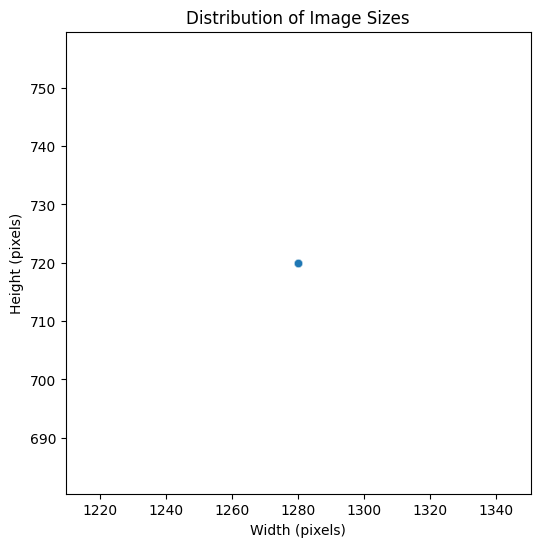

In [34]:
#1. summary of stats of size of the dataset
print(metaa[["height","width"]].describe())

# 2. Scatter plot to see aspect ratios
plt.figure(figsize=(6, 6))
sns.scatterplot(data=metaa, x="width", y="height", alpha=0.5)
plt.title("Distribution of Image Sizes")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

Observation :
1. The Dataset Has Uniform Image Sizes
2. The Exact Dimensions Are 1280 x  720
3. we will not need resize in transform 

* **Size in bytes for images**

In [40]:
metaa["size_bytes"].nunique()

1

observation : 
1. this means size in bytes for every image is same.

* **Pixel Intensities & Lighting (mean_intensity, dark_pixel_percentage, etc.)**

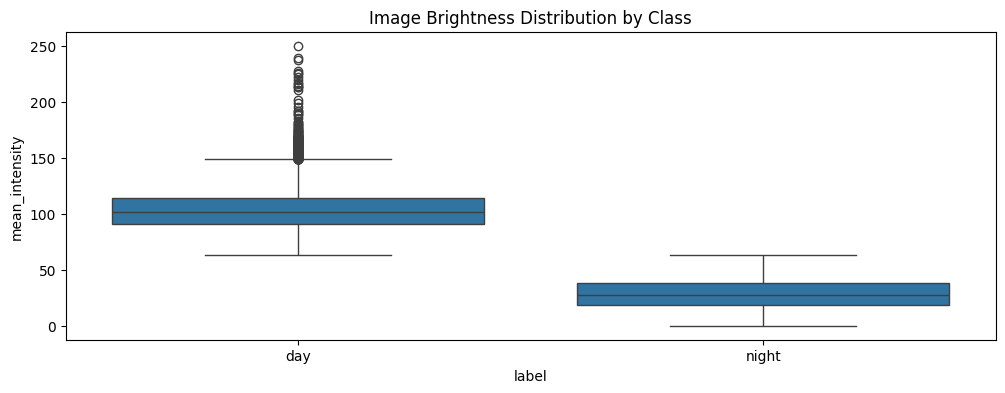

In [41]:
plt.figure(figsize=(12, 4))

# Plotting distribution of mean brightness across different classes
sns.boxplot(data=metaa, x="label", y="mean_intensity")
plt.title("Image Brightness Distribution by Class")
plt.show()

Observation :
* The boxplot demonstrates a clear distinction between classes: **day** images are significantly brighter with a mean intensity around 100, while **night** images consistently cluster at a much darker mean of around 30.
* The minimal overlap between the two distributions indicates that `mean_intensity` is a highly separable and distinct feature.
* Consequently, this feature holds high **feature importance** and will serve as a strong predictive signal for a machine learning model to easily differentiate between day and night scenes.

--- Advanced Contrast & Intensity Distribution ---
       median_intensity  std_intensity  dynamic_range  dark_pixel_percentage  \
count      61966.000000   61966.000000   61966.000000           61966.000000   
mean          61.737146      49.829891     253.497273              48.522023   
std           40.650840      17.193199       3.596835              31.373811   
min            0.000000       3.718682      81.000000               0.000000   
25%           21.000000      34.927936     253.000000              21.195394   
50%           65.000000      54.926454     255.000000              36.414497   
75%           93.000000      63.402441     255.000000              82.729167   
max          254.000000      93.258120     255.000000              99.929905   

       bright_pixel_percentage  
count             61966.000000  
mean                  6.288142  
std                   6.840539  
min                   0.000000  
25%                   0.902696  
50%                   4.386122

/tmp/ipykernel_212/2054477019.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_212/2054477019.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


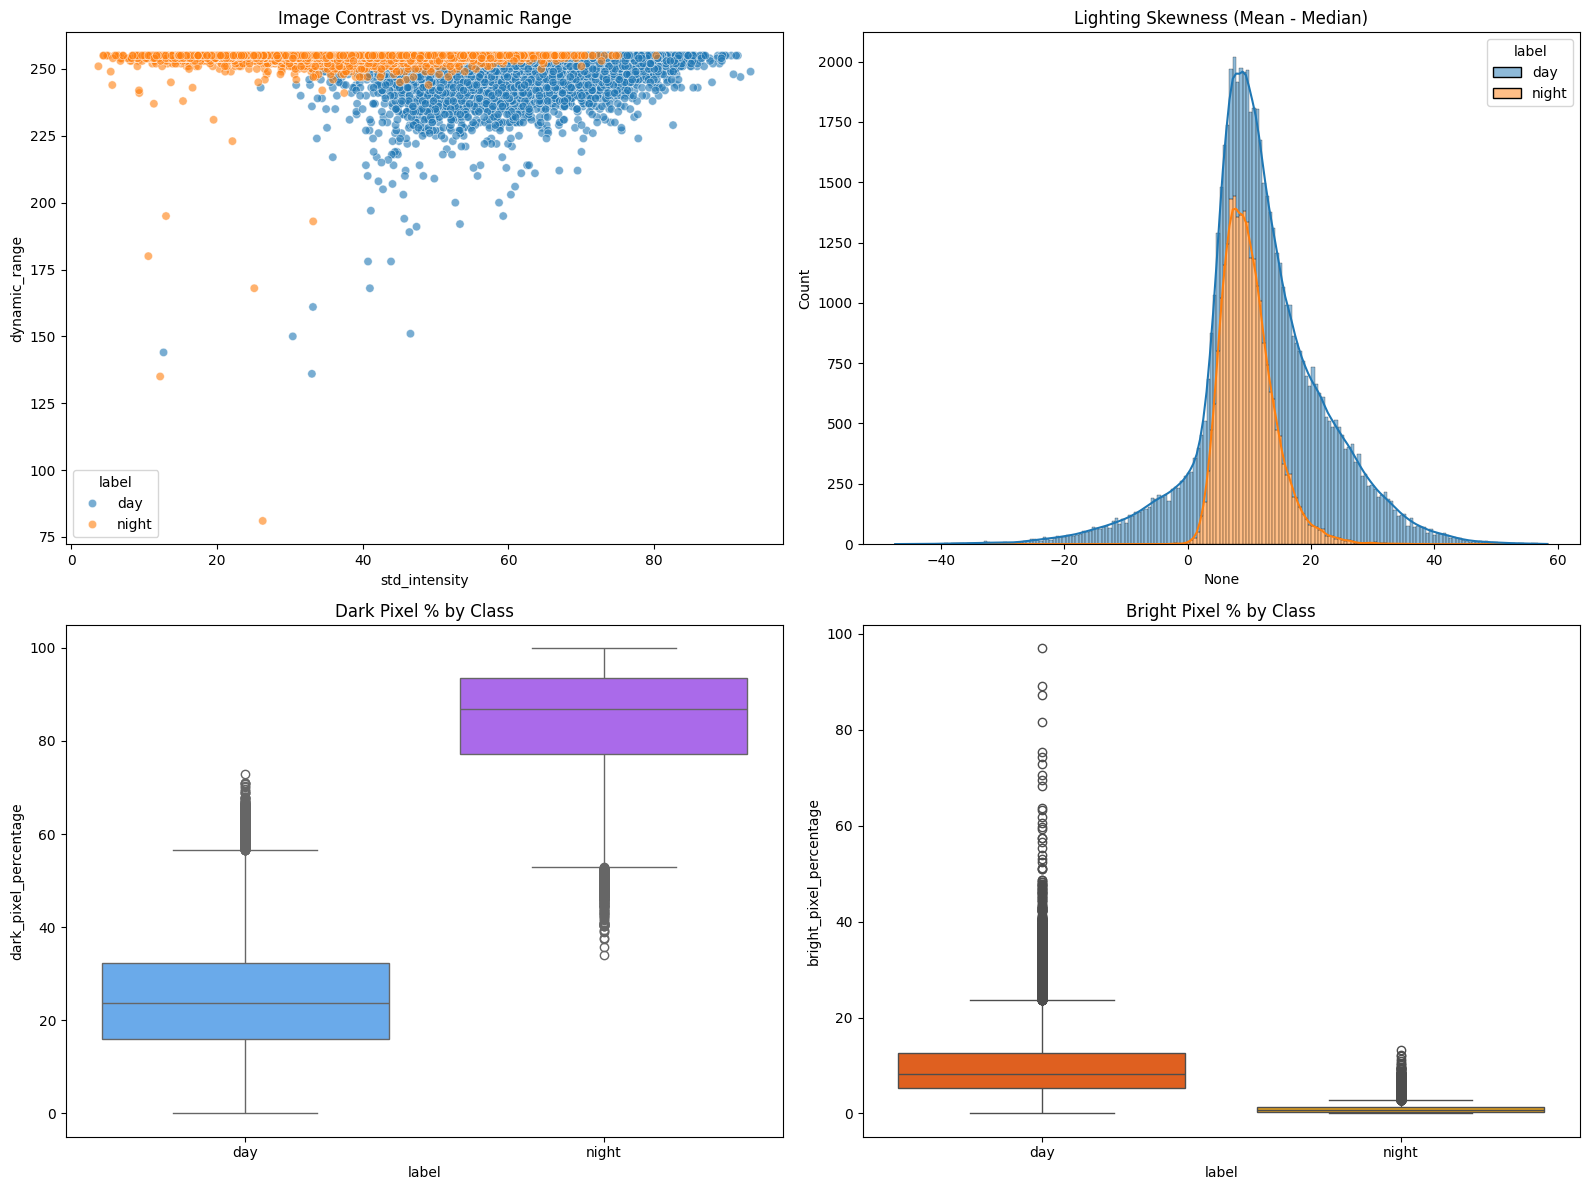

In [46]:
print("--- Advanced Contrast & Intensity Distribution ---")
advanced_cols = [
    "median_intensity",
    "std_intensity",
    "dynamic_range",
    "dark_pixel_percentage",
    "bright_pixel_percentage",
]
print(metaa[advanced_cols].describe())

# Set up a grid of plots to see everything at once
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Contrast Comparison (Std Dev vs Dynamic Range)
sns.scatterplot(
    data=metaa,
    x="std_intensity",
    y="dynamic_range",
    hue="label",
    ax=axes[0, 0],
    alpha=0.6,
)
axes[0, 0].set_title("Image Contrast vs. Dynamic Range")

# 2. Skewness (Mean vs Median Intensity)
# If mean and median are far apart, the lighting is highly skewed
sns.histplot(
    data=metaa,
    x=metaa["mean_intensity"] - metaa["median_intensity"],
    hue="label",
    kde=True,
    ax=axes[0, 1],
    multiple="stack",
)
axes[0, 1].set_title("Lighting Skewness (Mean - Median)")

# 3. Dark Pixel Percentage Distribution
sns.boxplot(
    data=metaa, x="label", y="dark_pixel_percentage", ax=axes[1, 0], palette="cool"
)
axes[1, 0].set_title("Dark Pixel % by Class")

# 4. Bright Pixel Percentage Distribution
sns.boxplot(
    data=metaa,
    x="label",
    y="bright_pixel_percentage",
    ax=axes[1, 1],
    palette="autumn",
)
axes[1, 1].set_title("Bright Pixel % by Class")

plt.tight_layout()
plt.show()

**Image Contrast vs Dynamic Range**
- Night pictures (orange) have very low overall contrast but still hit maximum brightness values because of small, intense light sources like streetlights or headlights.

- Day pictures (blue) have much higher contrast and are spread out widely because daytime lighting and shading vary naturally across the images.

- The heavy overlap at the top means these numbers alone aren't enough to separate them, so an AI model must look at actual shapes and objects to tell day from night accurately.

**Lighting skewnees (mean - median)**
- Night images (orange) are highly predictable with a narrow, uniform lighting balance because they almost always consist of dark backgrounds mixed with isolated bright spots.

- Day images (blue) are incredibly varied and spread out, meaning their lighting changes drastically based on different shadows, sun angles, and weather conditions.

- For an AI model, the chaotic variety in daytime photos makes them much harder to learn and generalize compared to the highly consistent patterns found in nighttime photos.

**Dark Pixel % by class**
- Night pictures (purple) are heavily dominated by darkness, with most images having between 75% and 95% purely dark pixels.

- Day pictures (blue) have a much lower presence of dark pixels, typically hovering down between 15% and 35%.

- The scattered dots show exceptions, like exceptionally dark shadows during the day or heavily lit scenes at night, which are the main areas where an AI could get confused.

**Bright pixel % by class**
- Daytime pictures naturally contain a much higher amount of bright, white areas from things like sunlight or the sky.

- Nighttime pictures are mostly dark and compressed right at the bottom of the chart near zero percent.

- The scattered dots represent exceptions like blinding daytime glare or bright night headlights that can easily trick an AI model.

## EDA

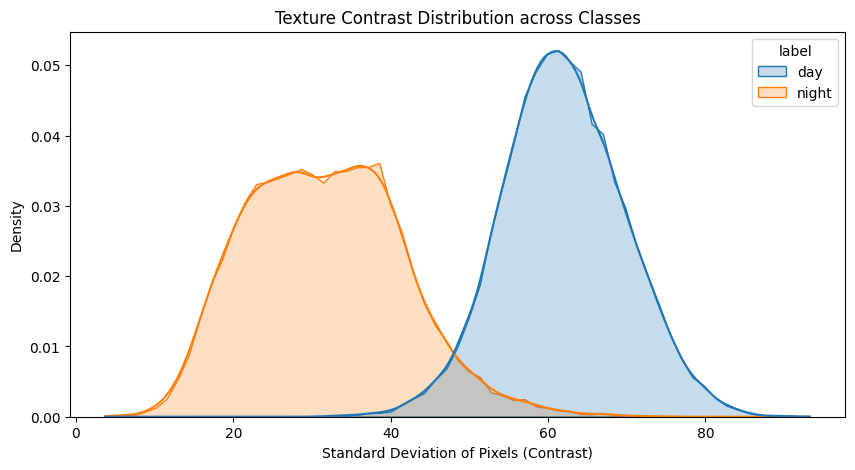

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(
    data=metaa,
    x="std_intensity",
    hue="label",
    kde=False,
    element="poly",
    stat="density",
    common_norm=False,
)
plt.title("Texture Contrast Distribution across Classes")
plt.xlabel("Standard Deviation of Pixels (Contrast)")
plt.ylabel("Density")
plt.show()

* **Texture Contrast across classes**
    * Day and night images are seperable by the Std this:
    * Day images are brighter so they have high std and for night, in contrast it is smaller
      

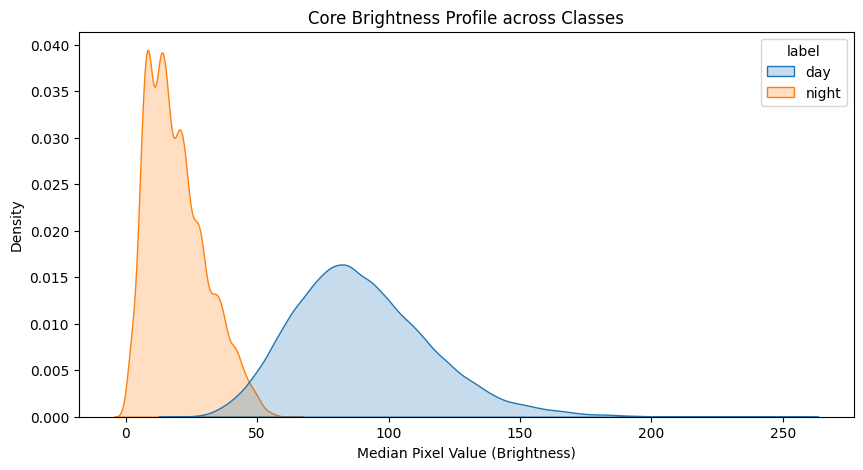

In [56]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=metaa, x="median_intensity", hue="label", fill=True, common_norm=False
)
plt.title("Core Brightness Profile across Classes")
plt.xlabel("Median Pixel Value (Brightness)")
plt.ylabel("Density")
plt.show()

* **Core Brightness Profile Across Classes**
- The `night` class peaks aggressively at a very low pixel value range ($10 - 20$), while the `day` class presents a wider distribution centered much higher ($\approx 85$).

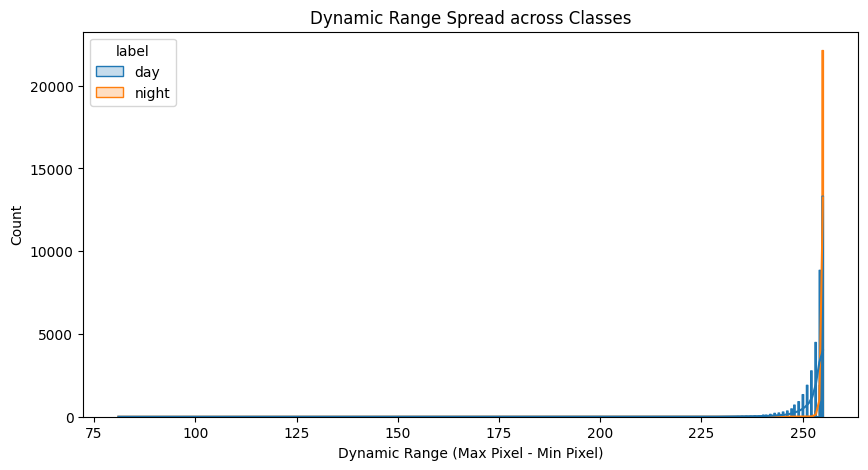

In [57]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=metaa, x="dynamic_range", hue="label", kde=True, element="step"
)
plt.title("Dynamic Range Spread across Classes")
plt.xlabel("Dynamic Range (Max Pixel - Min Pixel)")
plt.ylabel("Count")
plt.show()

# Dynamic range spread across classes 
   - This indicates that almost every image in the dataset utilizes the full available bit-depth—containing both near-zero shadow points and near-255 highlights. Even within dark `night` scenes, specular highlights (e.g., streetlights, vehicle lamps) successfully span the full contrast scale.

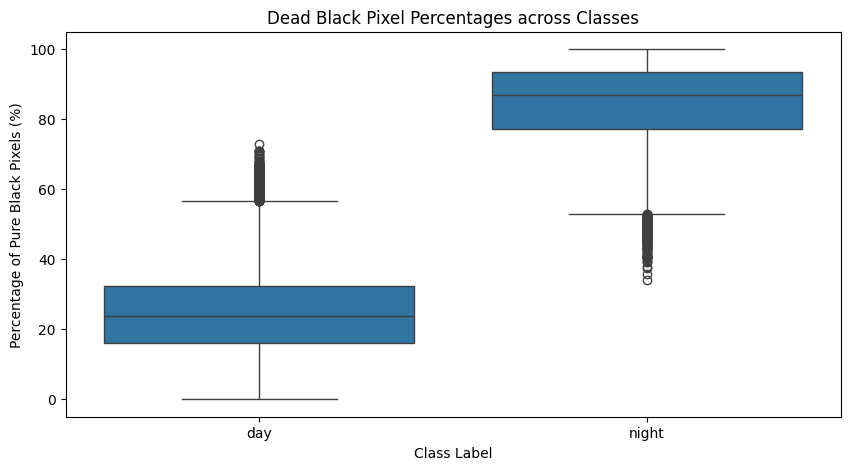

In [58]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=metaa, x="label", y="dark_pixel_percentage")
plt.title("Dead Black Pixel Percentages across Classes")
plt.xlabel("Class Label")
plt.ylabel("Percentage of Pure Black Pixels (%)")
plt.show()

* **Black pixel % across classes**
      - this shows  that the night images have more  value for this and day images ahve less values which is ideaaly good 

/tmp/ipykernel_212/2288013297.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metaa, x="label", y="bright_pixel_percentage", palette="autumn")


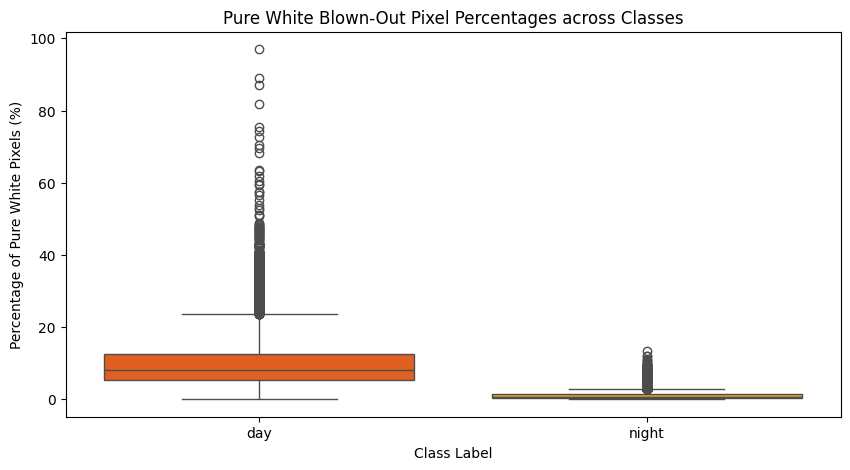

In [59]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=metaa, x="label", y="bright_pixel_percentage", palette="autumn")
plt.title("Pure White Blown-Out Pixel Percentages across Classes")
plt.xlabel("Class Label")
plt.ylabel("Percentage of Pure White Pixels (%)")
plt.show()

* **Bright pixels % across class**
    - This hows that Night outliers (<15%) capture localized streetlights and headlights, while massive day spikes (<100%) represent severe sun glare or overexposed skies.